Ejecución finalizada.


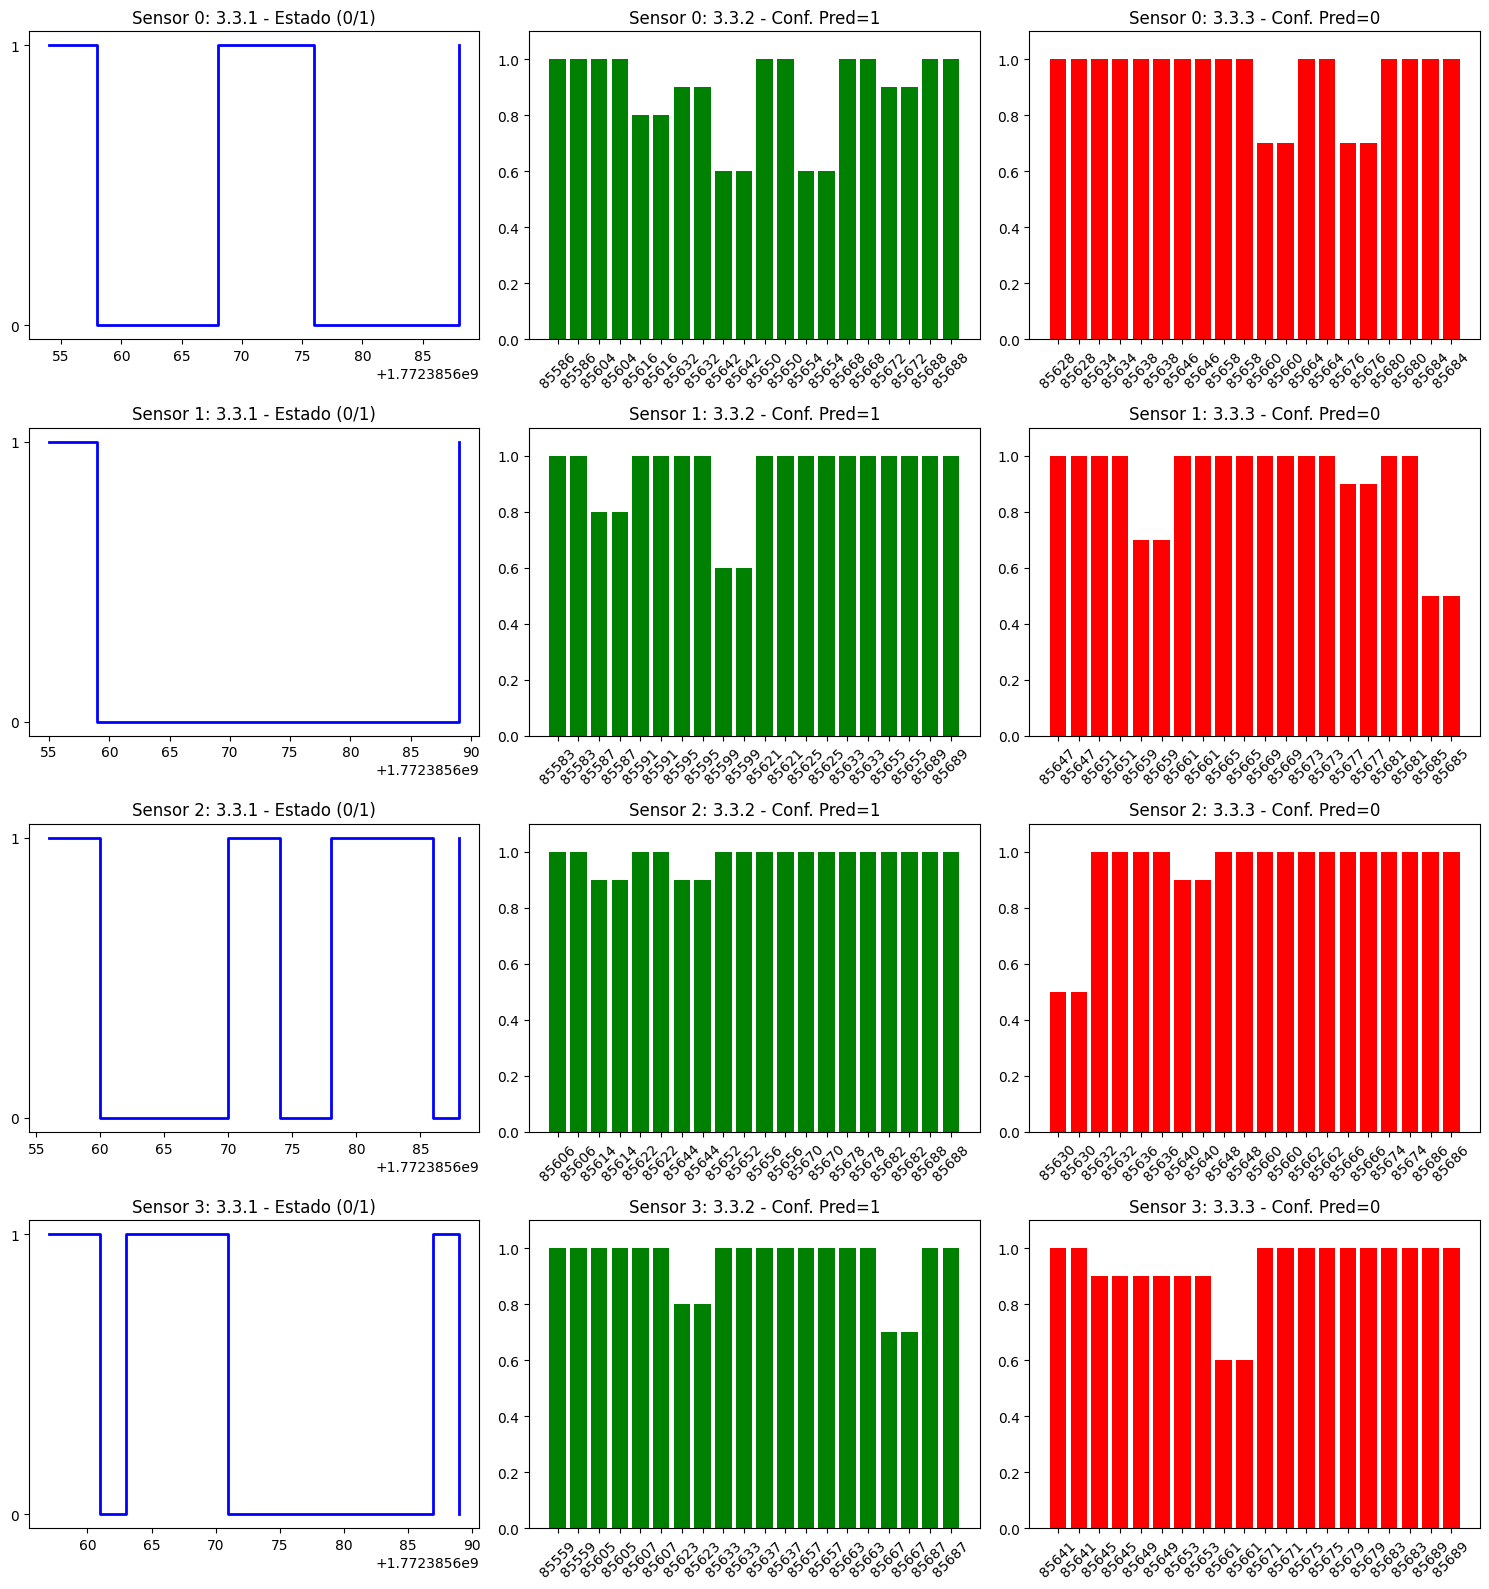

In [ ]:
%matplotlib inline
import json
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from kafka import KafkaConsumer
from collections import defaultdict

# Configuración
KAFKA_BOOTSTRAP_SERVERS = ["localhost:9092"]
OUTPUT_TOPIC = "aeration_predictions"
MAX_POINTS = 20
PLOT_EVERY = 5 

sensor_store = defaultdict(lambda: {
    'ts': [], 'pred': [],
    'ts_aer': [], 'conf_aer': [],
    'ts_no_aer': [], 'conf_no_aer': []
})

def plot_all_dashboards(store):
    """Genera, muestra y guarda **un único dashboard** con todos los sensores."""
    n_sensors = len(store)
    if n_sensors == 0: return

    # Crea una cuadrícula: n_sensors filas x 3 columnas
    fig, axes = plt.subplots(n_sensors, 3, figsize=(15, 4 * n_sensors))
    
    # Ajuste por si de momento solo ha llegado 1 sensor (para que no falle el indexado)
    if n_sensors == 1: axes = [axes]

    for idx, (sensor_id, sd) in enumerate(store.items()):
        # 3.3.1 Estado de aireación (Columna 0)
        if sd['ts']:
            axes[idx][0].step(sd['ts'], sd['pred'], where='post', color='blue', lw=2)
        axes[idx][0].set_title(f'Sensor {sensor_id}: 3.3.1 - Estado (0/1)')
        axes[idx][0].set_yticks([0, 1])

        # 3.3.2 Confianza (Pred == 1) (Columna 1)
        if sd['ts_aer']:
            axes[idx][1].bar(range(len(sd['ts_aer'])), sd['conf_aer'], color='green')
            axes[idx][1].set_xticks(range(len(sd['ts_aer'])))
            axes[idx][1].set_xticklabels([str(t)[-5:] for t in sd['ts_aer']], rotation=45)
        axes[idx][1].set_title(f'Sensor {sensor_id}: 3.3.2 - Conf. Pred=1')
        axes[idx][1].set_ylim(0, 1.1)

        # 3.3.3 Confianza (Pred == 0) (Columna 2)
        if sd['ts_no_aer']:
            axes[idx][2].bar(range(len(sd['ts_no_aer'])), sd['conf_no_aer'], color='red')
            axes[idx][2].set_xticks(range(len(sd['ts_no_aer'])))
            axes[idx][2].set_xticklabels([str(t)[-5:] for t in sd['ts_no_aer']], rotation=45)
        axes[idx][2].set_title(f'Sensor {sensor_id}: 3.3.3 - Conf. Pred=0')
        axes[idx][2].set_ylim(0, 1.1)

    plt.tight_layout()
    # **Guarda una sola imagen grande**
    plt.savefig('dashboard_todos_sensores.png')
    display(fig)
    plt.close(fig)

# Inicialización
consumer = KafkaConsumer(
    OUTPUT_TOPIC,
    bootstrap_servers=KAFKA_BOOTSTRAP_SERVERS,
    value_deserializer=lambda m: json.loads(m.decode('utf-8'))
)

msg_counter = 0

try:
    for message in consumer:
        res = message.value
        sid = res['sensor_id']
        ts = res['timestamp']
        pred = res['prediction']
        
        # Guardar en memoria
        sd = sensor_store[sid]
        sd['ts'].append(ts)
        sd['pred'].append(pred)
        
        if pred == 1:
            sd['ts_aer'].append(ts)
            sd['conf_aer'].append(res['proba_aeration'])
        else:
            sd['ts_no_aer'].append(ts)
            sd['conf_no_aer'].append(res['proba_no_aeration'])

        # Mantener tamaño máximo
        for k in sd: sd[k] = sd[k][-MAX_POINTS:]

        msg_counter += 1
        
        # Imprime por pantalla
        print(f"Sensor {sid} | Pred: {pred} | Prob(0): {res['proba_no_aeration']} | Prob(1): {res['proba_aeration']}")

        # **Actualiza la super-gráfica pasándole el diccionario entero**
        if msg_counter % PLOT_EVERY == 0:
            clear_output(wait=True)
            plot_all_dashboards(sensor_store)

except KeyboardInterrupt:
    print("Ejecución finalizada.")